### Predicting Loan Amount Based on Income Using Simple Linear Regression in Banking

### Step 1 : Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load Dataset (Synthetic Banking Data)

In [3]:
#It will always generate the same sequence of random numbers
np.random.seed(42) 

n = 500

# It will generate n 500 values, mean would be 50000 and standard deviation is 15000
annual_income = np.random.normal(50000, 15000, n)

# This will set the loan amount as 20% of the income however, it is not strictly following that rule as we are adding more data with mean of 1000 and standard deviation of 2000
loan_amount = annual_income * 0.2 + np.random.normal(1000, 2000, n)

In [4]:
data = pd.DataFrame({
    'Annual Income' : annual_income,
    'Loan Amount' : loan_amount
})
data.head()

,Annual Income,Loan Amount
0,57450.712295,14342.497554
1,47926.035482,14404.040377
2,59715.328072,10145.930467
3,72845.447846,16695.028043
4,46487.699379,8996.254738


### Step 3: Data Preprocessing

In [6]:
X = data[['Annual Income']]
y = data[['Loan Amount']]

#### Split the dataset into training and test dataset

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#### Standardization

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

### Step 4: Simple Linear Regression Model

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [39]:
pred = model.predict(X_test_scaled)

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

print('Linear Regression R2 score : ', r2_score(y_test, pred))
print('Linear Regression MSE score : ', mean_squared_error(y_test, pred))

Linear Regression R2 score :  0.60647263117856
Linear Regression MSE score :  4384651.761506158


### Step 5: Ridge (L2) Regularization with GridSearchCV

In [52]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

params = {'alpha' : [0.01, 0.1, 1, 10, 100]}
ridge = Ridge()

grid_ridge = GridSearchCV(ridge, params, cv=5)
grid_ridge.fit(X_train_scaled, y_train)

print('Best Ridge Alpha : ', grid_ridge.best_params_)
print('R2 Score (Ridge) : ', grid_ridge.score(X_test_scaled, y_test))

Best Ridge Alpha :  {'alpha': 0.1}
R2 Score (Ridge) :  0.606499803575171


### Step 6: Lasso (L1) Regularization with RandomizedSearchCV

In [65]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV

lasso = Lasso()
random_lasso = RandomizedSearchCV(lasso, {'alpha' : np.linspace(0.001, 1, 100)}, cv=5, n_iter=10, random_state=42)

random_lasso.fit(X_train_scaled, y_train)

print('Best Lasso Alpha : ', random_lasso.best_params_)
print('R2 Score (Lasso) : ', random_lasso.score(X_test_scaled, y_test))

Best Lasso Alpha :  {'alpha': 0.8385454545454546}
R2 Score (Lasso) :  0.6065047776452392


### Step 7: Ridge with Bayesian Optimization

In [79]:
from skopt import BayesSearchCV
from skopt.space import Real

opt_ridge = BayesSearchCV(Ridge(), 
                        {'alpha' : Real(1e-3, 1e-2, prior = 'log-uniform')},
                          n_iter = 20,
                         cv = 5,
                         random_state = 42)

opt_ridge.fit(X_train_scaled, y_train)

print('Best Alpha (Bayesian Ridge) : ', opt_ridge.best_params_)
print('R2 Score (Bayesian Ridge) : ', opt_ridge.score(X_test_scaled, y_test))

Best Alpha (Bayesian Ridge) :  OrderedDict({'alpha': 0.009563541629317312})
R2 Score (Bayesian Ridge) :  0.6064752343077753


### Step 8: Visualize Predictions

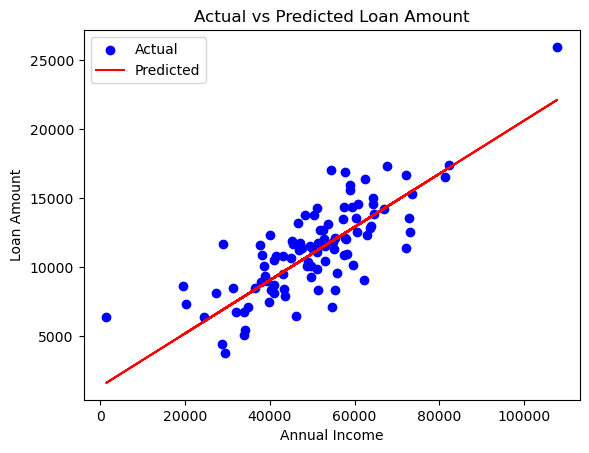

In [88]:
plt.scatter(X_test, y_test, color = 'blue', label = 'Actual')
plt.plot(X_test, pred, color = 'red', label = 'Predicted')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.title('Actual vs Predicted Loan Amount')
plt.legend()
plt.show()